In [1]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt

In [2]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
start_of_sentence =" "

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [3]:
def p1_new(dialog, start_of_sentence):
    max_length = model.config.n_positions
    stride = 1
    encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")
    seq_len = encodings.input_ids.size(1)
    nlls = []
    for end_loc in tqdm(range(1, seq_len + 1, stride)):
        begin_loc = max(end_loc - max_length, 0)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-stride] = -100

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss

        nlls.append(neg_log_likelihood.item())

    return nlls

In [9]:
def create_extended_list(lst, arr):
    result = []
    prev_count = 0
    for i, count in enumerate(arr):
        result.extend([lst[i]] * (count - prev_count))
        prev_count = count
    return result

def compute_p3(dialog, perplexity_scores_p1, pattern = '<(SPK[1-9]|MOD)>'):
    assert len(perplexity_scores_p1) == tokenizer("".join(dialog), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)
    tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog]
    assert len(torch.cat(tokens)) == len(perplexity_scores_p1)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens])
    value = np.asarray([0] + list(np.asarray(perplexity_scores_p1)[tokens_ids_per_sentence[:-1]]))
    tokens_value = np.asarray([0] + list(np.asarray(torch.cat(tokens))[tokens_ids_per_sentence[:-1]]))
    perplexity_scores_p3 = create_extended_list(value, tokens_ids_per_sentence)
    assert len(perplexity_scores_p3) == tokenizer("".join(dialog), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)

    return perplexity_scores_p3

def mean_p_per_speaker(tokens, perplexity_scores):
    spk1 = []
    spk2 = []
    start = 0

    for i, token_tensor in enumerate(tokens):
        length = len(token_tensor)
        segment = perplexity_scores[start:start + length]
        avg_value = np.nanmean(segment)

        if i % 2 == 0:
            spk1.append(avg_value)
        else:
            spk2.append(avg_value)

        start += length

    return (np.mean(spk1), np.mean(spk2))

In [5]:
def compute_graph_perplexity(tokens, p1, p2, matches, pattern = '<(SPK[1-9]|MOD)>', answers=None):
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in tokens]
    unique_matches = np.unique(matches)
    
    # rows = int(np.ceil(np.sqrt(len(dialog))))
    rows = int(np.ceil(len(dialog)/6.0))
    # Create an 8x8 grid of subplots
    fig, axes = plt.subplots(rows, 6, figsize=(30, 15))
    num_plots = len(dialog)
    # Set smaller font size
    plt.rcParams.update({'font.size': 8})
    
    assert num_plots == len(matches)
    encodings = torch.cat(tokens)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens])
    assert tokens_ids_per_sentence[-1] == len(p1)
    
    # Compute global y-limits across all p1 and p2 values
    all_values = []
    prev_idx_pp = 0
    for idx in range(len(dialog)):
        idx_pp = tokens_ids_per_sentence[idx]
        p1_per_sent = p1[prev_idx_pp:idx_pp]
        p2_per_sent = p2[prev_idx_pp:idx_pp]
        all_values.extend(p1_per_sent)
        all_values.extend(p2_per_sent)
        prev_idx_pp = idx_pp

    # Filter out NaNs and compute global limits
    all_values = np.array(all_values)
    global_min = np.nanmin(all_values)
    global_max = np.nanmax(all_values)

    prev_idx_pp = 0
    for idx, ax in enumerate(axes.flatten()):
        if idx < num_plots:
            idx_pp = tokens_ids_per_sentence[idx]
            patt = matches[idx]
            tokens = encodings[prev_idx_pp:idx_pp]
            decoded = [tokenizer.decode([token], skip_special_tokens=True) for token in tokens]
            p1_per_sent = p1[prev_idx_pp:idx_pp]
            p2_per_sent = p2[prev_idx_pp:idx_pp]
            ax.plot(np.asarray(p1_per_sent), label=f'{patt} p1')
            #ax.plot(np.asarray(p2_per_sent), label=f'{patt} p2', color='r')
            #mean_value=np.nanmean(np.asarray(perpl_per_sent))
            # ax.axhline(p1_per_sent[0], color='g', label=f'{patt} p3')  # Fixed the color argument
            ax.plot(np.asarray(p2_per_sent), label=f'{patt} p3', color='g')
            ax.set_xticks(np.arange(len(decoded)))
            ax.set_xticklabels(decoded, rotation=90)
            if answers is not None:
                ax.set_title(f'{answers[idx]}')
            ax.legend()
            prev_idx_pp=idx_pp

            ax.set_ylim(global_min, global_max)

    # Hide any remaining empty subplots
    for ax in axes.flatten()[num_plots:]:
        ax.axis('off')
        
    plt.subplots_adjust(hspace=0.5, top=0.95)  
    plt.suptitle("Per-Word Perplexity across the Dataset", fontsize=30)
    plt.legend()
    plt.show()

In [6]:
el=" <SPK1> So, thanks for coming today. We're going to play a quick quiz. I’m going to ask you three questions, and I would like you to guess the three most popular answers to these questions, which were posed to a group of one hundred people. <SPK1> Ok, sounds good. <SPK1> Alright, I’m going to ask the first question: What do people normally use to transport patients in a hospital? Think about things like an ambulance, a wheelchair, or a patient's bed. What would you say, <SPK2> ? <SPK2> Mhmm… um, ambulance? <SPK1> Correct, and can you guess the next two most popular answers? <SPK2> Hmm... wheelchair? <SPK1> Yes, good! And the third one? <SPK2> Maybe... a stretcher? <SPK1> Exactly! Well done. Now, let's move on to the second question. This one is a little different: What do you think is the most popular type of vacation destination? Some of the answers we got were beach resorts, mountain retreats, and city stays. Can you guess the top three? <SPK2> Uh… beach resorts? <SPK1> Yes, that’s number one! What about number two? <SPK2> Mountain retreat? <SPK1> Exactly. And number three? <SPK2> Uh… city stays? <SPK1> Perfect! Now we have the last one: What is the most common drink people enjoy at breakfast? Can you guess? <SPK2> Coffee? <SPK1> Right! What else? <SPK2> Maybe... juice? <SPK1> Correct! And the third one? <SPK2> Milk? <SPK1> Yes, that’s exactly right! Well done! You got all the answers!"
el_first_dominant = """
<SPK1> You know, I think most people do not take care of their health enough.  
<SPK2> Hmm, maybe. I try to eat healthy when I can.  
<SPK1> That is not enough. You need a routine with healthy food, exercise, and good sleep.  
<SPK2> I guess you are right. I do sleep late a lot.  
<SPK1> That is bad for your body. I wake up early and go running every morning.  
<SPK2> Really? Every morning? That sounds hard.  
<SPK1> It is at first. But once you start, it becomes easy. You just need discipline.  
<SPK2> I want to start something like that, but I do not know where to begin.  
<SPK1> Start with small steps. Go for a walk every day. Then add more.  
<SPK2> Okay, that sounds possible. I think I can do that.  
<SPK1> Also, stop eating junk food. It makes you tired and lazy.  
<SPK2> I do eat fast food sometimes… maybe too much.  
<SPK1> Cut it down. Try cooking at home. It is healthier and cheaper.  
<SPK2> I do not cook much. I do not know how to make many things.  
<SPK1> Learn. There are easy recipes online. No excuse not to try.  
<SPK2> You are right. I just need to stop being lazy about it.  
<SPK1> Exactly. Being healthy is your own choice. No one else can do it for you.  
<SPK2> That makes sense. I will try harder from now on.  
<SPK1> Good. Set a goal and stay with it. You will feel better in no time.  
<SPK2> Thank you. Talking to you really helped me think more seriously about it.
"""
el_second_dominant = """
<SPK1> I study English sometimes, but it is hard for me.
<SPK2> That is because you are not doing it every day. Are you practicing speaking often?
<SPK1> Not really. I just watch videos or read a little.
<SPK2> That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.
<SPK1> I feel shy when I speak. I think I make too many mistakes.
<SPK2> Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.
<SPK1> Maybe I should try more. I want to speak better.
<SPK2> Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.
<SPK1> That sounds like a lot. I am not sure I can do it.
<SPK2> You can. You just need to stop thinking and start doing. Use your time well. No excuses.
<SPK1> I guess I waste a lot of time on my phone.
<SPK2> Then use your phone for learning. Change your apps to English, listen to podcasts, use a dictionary app.
<SPK1> Those are good ideas. I never thought of that.
<SPK2> That is the problem. Most people want to improve but do not think smart. Be active. Control your learning.
<SPK1> I will try to change my habits.
<SPK2> Good. Start today, not tomorrow. Even ten minutes is better than nothing.
<SPK1> Alright. I will do something after this conversation.
<SPK2> That is the spirit. Keep going and do not stop. In a few months, you will see big changes.
<SPK1> Thank you for the advice. It is very helpful.
<SPK2> You are welcome. Now go and study. You have work to do.
"""

In [ ]:
# Make a copy of text
turn_based_el = el_second_dominant

# Speaker patterns
pattern='<(SPK[1-9]|MOD)>'

# Find duplicated consequative speakers to remove
speaker_tags_to_remove = []
last_match = None
for match in re.compile(pattern).finditer(turn_based_el):
    if match.group() == last_match:
        speaker_tags_to_remove.append((match.start(), match.end()))
    last_match = match.group()
speaker_tags_to_remove = sorted(speaker_tags_to_remove, reverse=True)

# Remove duplicated consequative speakers
for begin, end in speaker_tags_to_remove:
    turn_based_el = turn_based_el[:begin] + turn_based_el[end:]

# find matches and change speaker format
matches = re.findall(pattern, "".join(turn_based_el))
dialog = turn_based_el.replace("\n", "")
dialog = re.sub(r'\<', r'\n<', dialog).split("\n")[1:]
dialog = [d.strip() for d in dialog]
dialog_no_s = [re.sub(pattern," >", d) for d in dialog]
display(dialog_no_s)

[' > I study English sometimes, but it is hard for me.',
 ' > That is because you are not doing it every day. Are you practicing speaking often?',
 ' > Not really. I just watch videos or read a little.',
 ' > That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.',
 ' > I feel shy when I speak. I think I make too many mistakes.',
 ' > Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.',
 ' > Maybe I should try more. I want to speak better.',
 ' > Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.',
 ' > That sounds like a lot. I am not sure I can do it.',
 ' > You can. You just need to stop thinking and start doing. Use your time well. No excuses.',
 ' > I guess I waste a lot of time on my phone.',
 ' > Then use your phone for learning. Change your apps to English, listen to podcasts, use a dictionary app.',
 ' > Those are good ideas. I never

100%|██████████| 343/343 [00:07<00:00, 46.16it/s]


Correlation coef:
[[1.         0.04989807]
 [0.04989807 1.        ]]
Average P1 for speakers:(2.6000113300806187, 3.014000015244085)
Average P3 for speakers:(1.226824587583542, 1.7939524829387665)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


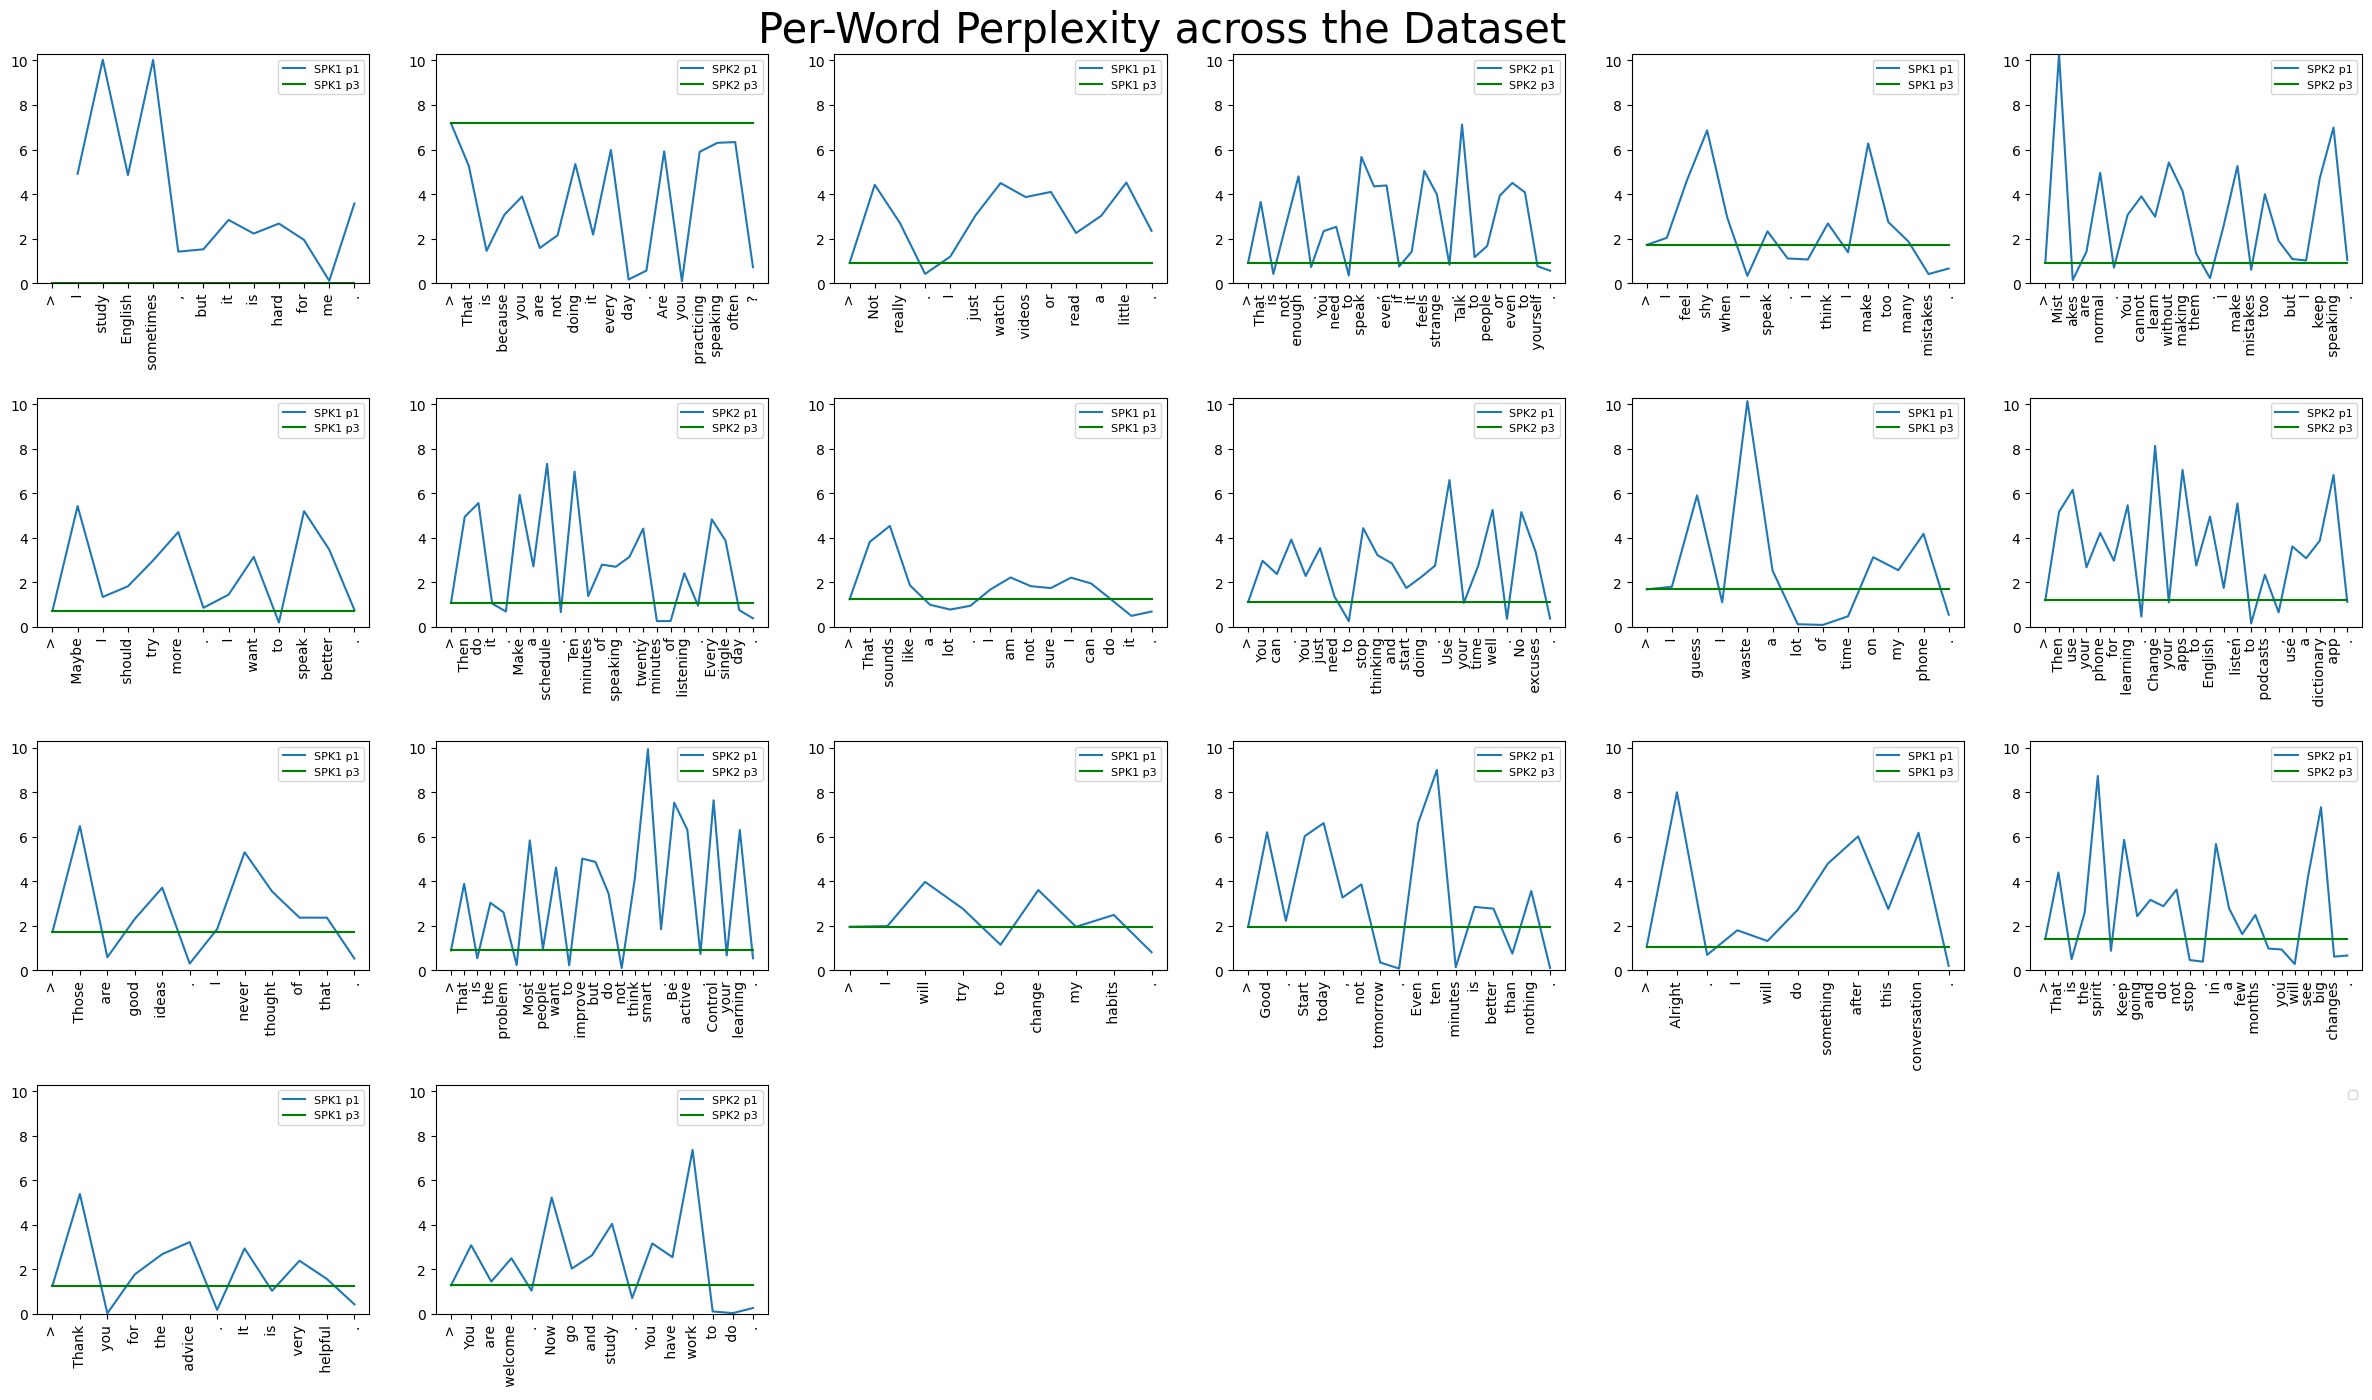

In [10]:
# assert len(perplexity_scores_p1) == tokenizer(" ".join(dialog_no_s), return_tensors="pt", return_offsets_mapping=True).input_ids.size(1)
# assert len(torch.cat(tokens)) == len(perplexity_scores_p1)
tokens = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog_no_s]
perplexity_scores_p1 = p1_new(dialog_no_s, start_of_sentence="")
perplexity_scores_p3 = compute_p3(dialog_no_s, perplexity_scores_p1)

print("Correlation coef:")
print(np.corrcoef(perplexity_scores_p1[1:], perplexity_scores_p3[1:]))
print(f"Average P1 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p1)}")
print(f"Average P3 for speakers:{mean_p_per_speaker(tokens, perplexity_scores_p3)}")
compute_graph_perplexity(tokens, perplexity_scores_p1, perplexity_scores_p3, matches, pattern=pattern)

Correlation coef with replaced ppl of speaker begin token:
[[1.         0.01977566]
 [0.01977566 1.        ]]
Average P1 for speakers:(2.827791897509184, 3.1587004338730713)
Average P3 for speakers:(1.226824587583542, 1.7939524829387665)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


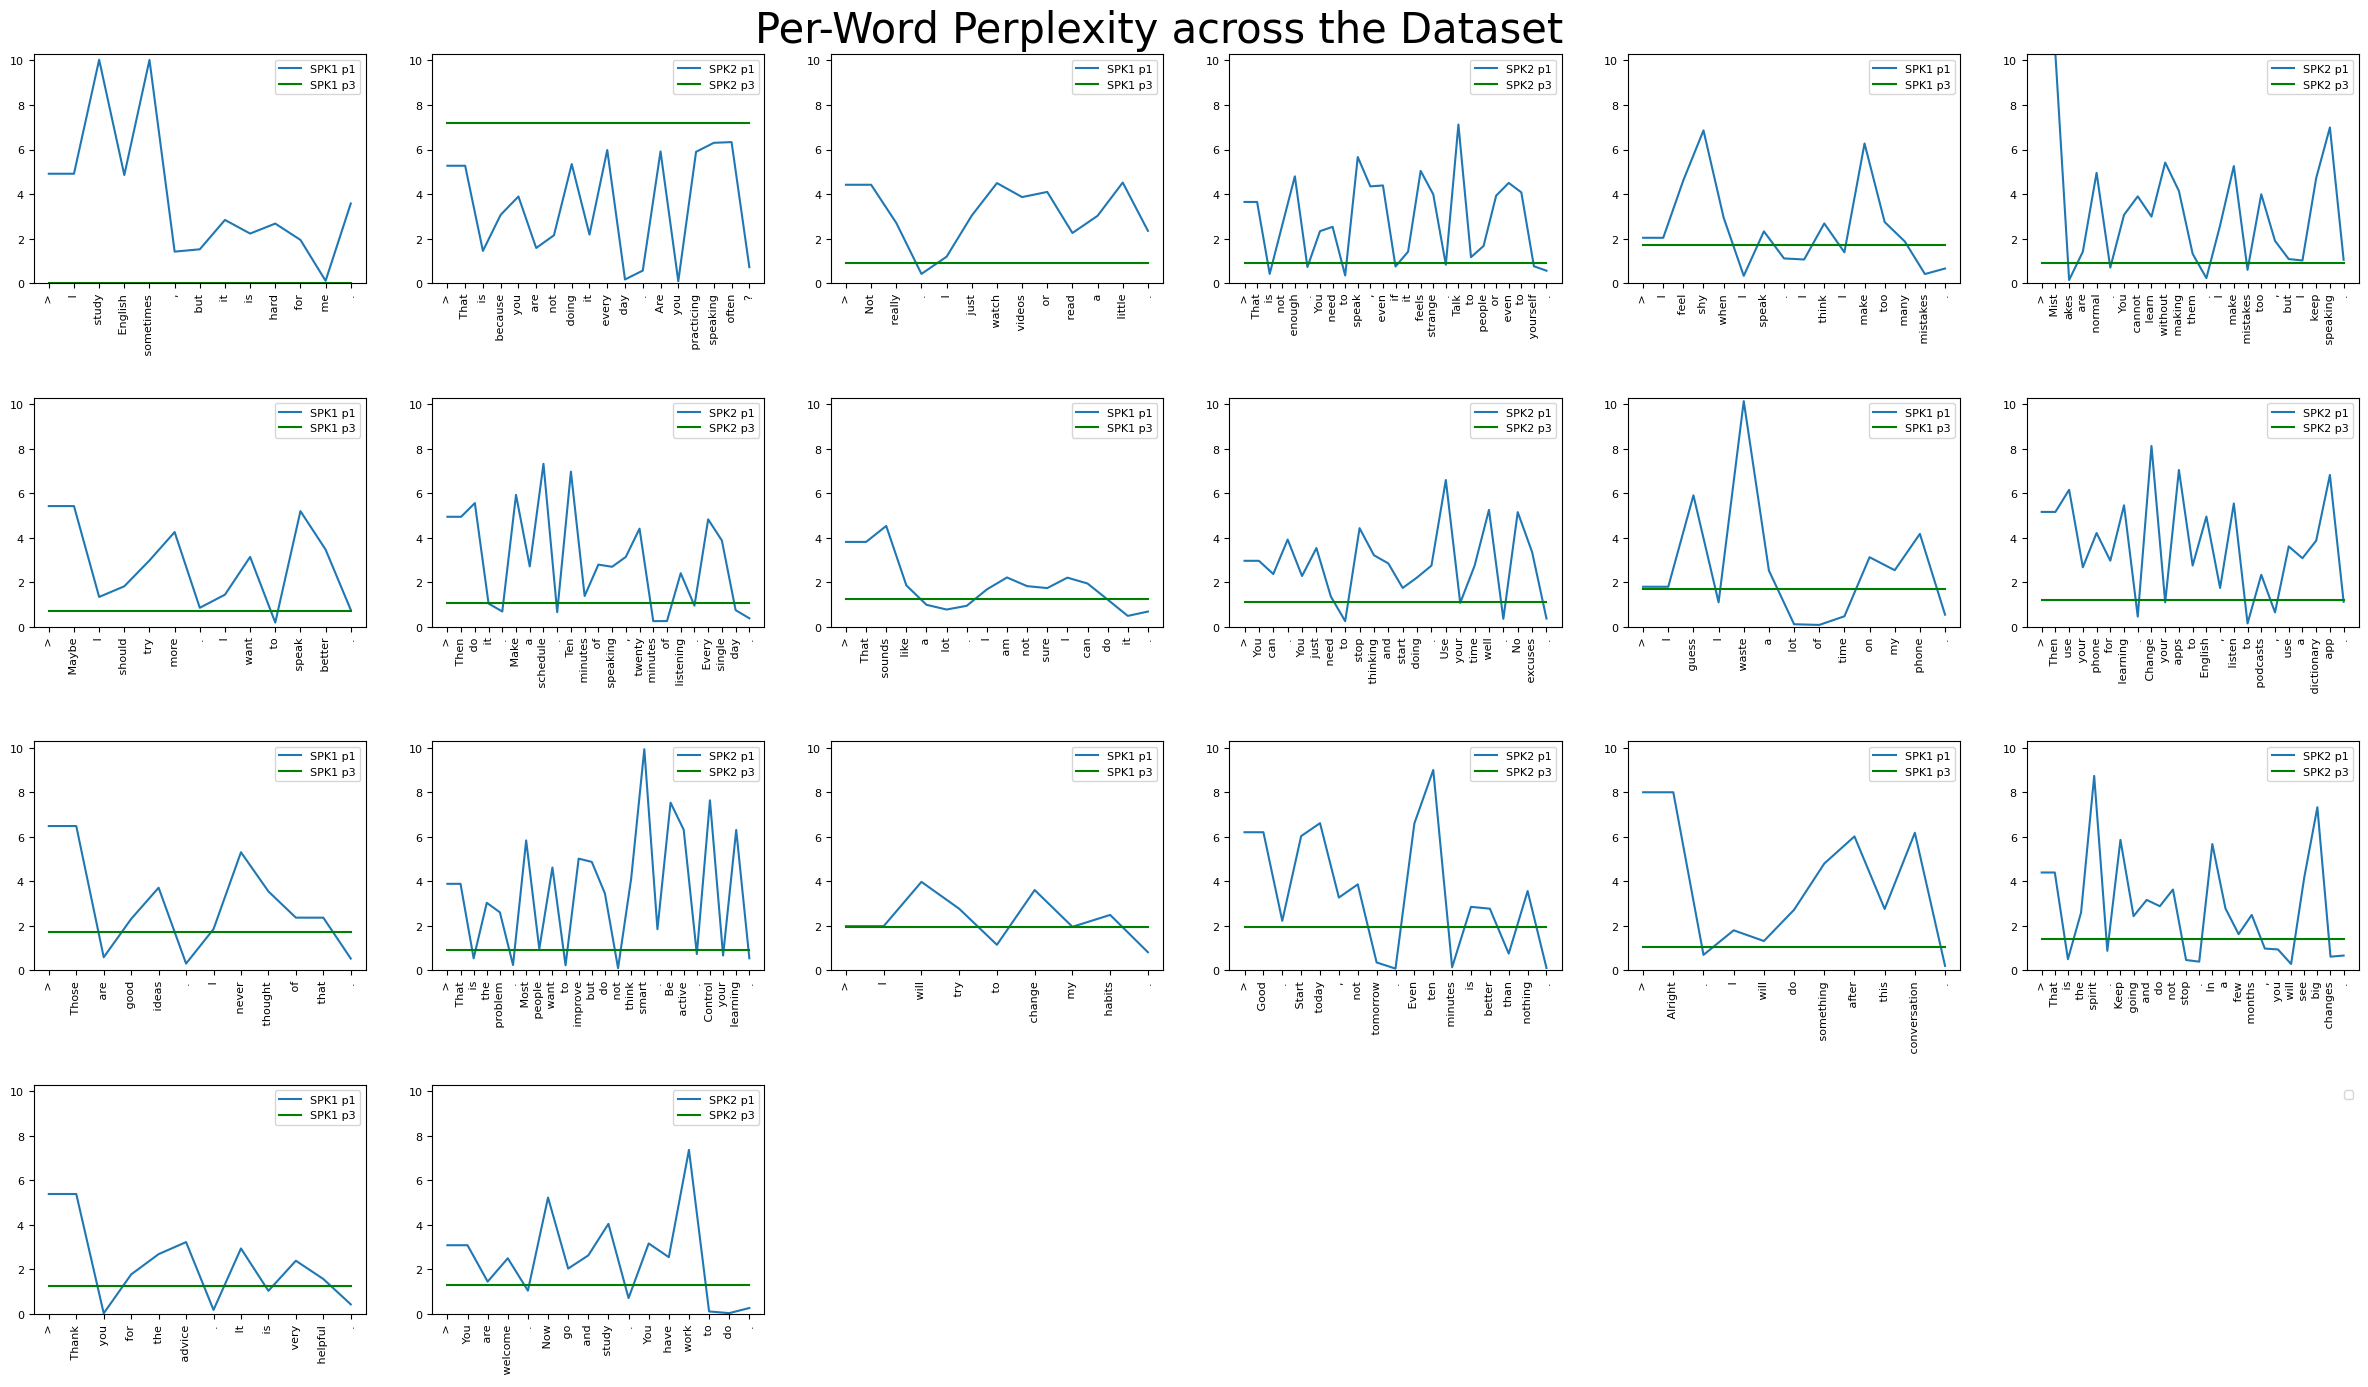

In [11]:
# V2: Update ppl of '>' tokens in p1 with the next token ppl
def p1_use_next_token_ppl_for_speaker_begin_token(tokens, perplexity_scores, begin_tokens = []):
    new_perplexity_scores = []
    for i, token in enumerate(torch.cat(tokens)):
        if token in begin_tokens:
            new_perplexity_scores.append(perplexity_scores[i+1])
        else:
            new_perplexity_scores.append(perplexity_scores[i])
    
    return new_perplexity_scores

dialog_no_s_V2 = dialog_no_s.copy() # no change
tokens_V2 = tokens.copy() # no change
perplexity_scores_p1_V2 = p1_use_next_token_ppl_for_speaker_begin_token(tokens, perplexity_scores_p1, [tokens_V2[0][0]])
perplexity_scores_p3_V2 = perplexity_scores_p3.copy() # no change

print("Correlation coef with replaced ppl of speaker begin token:")
print(np.corrcoef(perplexity_scores_p1_V2[1:], perplexity_scores_p3_V2[1:]))
print(f"Average P1 for speakers:{mean_p_per_speaker(tokens_V2, perplexity_scores_p1_V2)}")
print(f"Average P3 for speakers:{mean_p_per_speaker(tokens_V2, perplexity_scores_p3_V2)}")
compute_graph_perplexity(tokens, perplexity_scores_p1_V2, perplexity_scores_p3_V2, matches, pattern=pattern)

In [23]:
# V3: Use > and < for different speakers
for sp1_token, sp2_token in [('>', '<'), ('<', '>'), ('::', ';;'), (';;', '::'), ('1', '2'), ('2', '1'), ('-', '+'), ('+', '-')]:
    dialog_no_s_V3 = [d.replace('>', sp1_token, 1)  if i % 2 == 0 else d for i, d in enumerate(dialog_no_s)]
    dialog_no_s_V3 = [d.replace('>', sp2_token, 1)  if i % 2 == 1 else d for i, d in enumerate(dialog_no_s_V3)]
    tokens_V3 = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog_no_s_V3]
    perplexity_scores_p1_V3 = p1_new(dialog_no_s_V3, start_of_sentence="")
    perplexity_scores_p3_V3 = compute_p3(dialog_no_s_V3, perplexity_scores_p1_V3)

    perplexity_scores_p1_V3 = p1_use_next_token_ppl_for_speaker_begin_token(tokens_V3, perplexity_scores_p1_V3, [tokens_V3[0][0], tokens_V3[1][0]])
    print(f"spk1: {sp1_token}, spk2: {sp2_token}")
    print("Correlation coef with replaced ppl of speaker begin token (different token for different speaker):")
    print(np.corrcoef(perplexity_scores_p1_V3[1:], perplexity_scores_p3_V3[1:]))
    print(f"Average P1 for speakers:{mean_p_per_speaker(tokens_V3, perplexity_scores_p1_V3)}")
    print(f"Average P3 for speakers:{mean_p_per_speaker(tokens_V3, perplexity_scores_p3_V3)}")
    # compute_graph_perplexity(tokens_V3, perplexity_scores_p1_V3, perplexity_scores_p3_V3, matches, pattern=pattern)
    print()

100%|██████████| 343/343 [00:07<00:00, 43.64it/s]


spk1: >, spk2: <
Correlation coef with replaced ppl of speaker begin token (different token for different speaker):
[[1.         0.03819557]
 [0.03819557 1.        ]]
Average P1 for speakers:(2.8117328084000874, 3.1615182852307337)
Average P3 for speakers:(2.2103765964508058, 3.1282155394554136)



100%|██████████| 343/343 [00:07<00:00, 46.86it/s]


spk1: <, spk2: >
Correlation coef with replaced ppl of speaker begin token (different token for different speaker):
[[ 1.         -0.04013656]
 [-0.04013656  1.        ]]
Average P1 for speakers:(2.8467422930221273, 3.1391868555646156)
Average P3 for speakers:(3.0505629062652586, 1.8432126998901368)



100%|██████████| 343/343 [00:07<00:00, 46.63it/s]


...

spk1: 2, spk2: 1
Correlation coef with replaced ppl of speaker begin token (different token for different speaker):
[[ 1.         -0.00735642]
 [-0.00735642  1.        ]]
Average P1 for speakers:(2.9166651125333005, 3.2250030463015507)
Average P3 for speakers:(1.9864373683929444, 2.732191491127014)



100%|██████████| 343/343 [00:07<00:00, 46.85it/s]


spk1: -, spk2: +
Correlation coef with replaced ppl of speaker begin token (different token for different speaker):
[[1.         0.03640402]
 [0.03640402 1.        ]]
Average P1 for speakers:(2.7617976742470236, 3.1732361778879095)
Average P3 for speakers:(2.6005125045776367, 2.692263102531433)



100%|██████████| 343/343 [00:07<00:00, 43.20it/s]

spk1: +, spk2: -
Correlation coef with replaced ppl of speaker begin token (different token for different speaker):
[[1.         0.00510418]
 [0.00510418 1.        ]]
Average P1 for speakers:(2.851620932533634, 3.1576741525211354)
Average P3 for speakers:(2.736967670917511, 1.9896071076393127)



In [ ]:
# V4: 
def p3_new(dialog, start_of_sentence, spk1_begin_token, spk2_begin_token):
    max_length = model.config.n_positions
    # Fixed stride = 1 in this code
    # stride = 1
    encodings = tokenizer(start_of_sentence + f"{start_of_sentence}".join(dialog), return_tensors="pt")
    seq_len = encodings.input_ids.size(1)

    replace_token = spk1_begin_token
    nlls = []
    for end_loc in tqdm(range(1, seq_len + 1)):
        # find replace token
        if (replace_token == spk1_begin_token) and (encodings.input_ids[0, end_loc-1] == spk2_begin_token):
            replace_token = spk2_begin_token
        elif (replace_token == spk2_begin_token) and (encodings.input_ids[0, end_loc-1] == spk1_begin_token):
            replace_token = spk1_begin_token

        begin_loc = max(end_loc - max_length, 0)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)

        # replace token
        input_ids[:, -1] = replace_token
        
        target_ids = input_ids.clone()
        target_ids[:, :-1] = -100

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss

        nlls.append(neg_log_likelihood.item())

    return nlls

def agg_p3_new(tokens, perplexity_scores):
    new_perplexity_scores = []
    start = 0

    for token_tensor in tokens:
        length = len(token_tensor)
        segment = perplexity_scores[start:start + length]
        avg_value = np.nanmean(segment)
        new_perplexity_scores.extend([avg_value] * length)
        start += length

    return new_perplexity_scores

for sp1_token, sp2_token in [('>', '<'), ('<', '>'), ('::', ';;'), (';;', '::'), ('1', '2'), ('2', '1'), ('-', '+'), ('+', '-')]:
    dialog_no_s_V4 = [d.replace('>', sp1_token, 1)  if i % 2 == 0 else d for i, d in enumerate(dialog_no_s)]
    dialog_no_s_V4 = [d.replace('>', sp2_token, 1)  if i % 2 == 1 else d for i, d in enumerate(dialog_no_s_V4)]
    tokens_V4 = [tokenizer(section, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for section in dialog_no_s_V4]
    perplexity_scores_p1_V4 = p1_new(dialog_no_s_V4, start_of_sentence="")
    perplexity_scores_p3_V4 = p3_new(dialog_no_s_V4, start_of_sentence="", spk1_begin_token=tokens_V4[0][0], spk2_begin_token=tokens_V4[1][0])
    perplexity_scores_p3_V4 = agg_p3_new(tokens_V4, perplexity_scores_p3_V4)

    # perplexity_scores_p1_V4 = p1_use_next_token_ppl_for_speaker_begin_token(tokens_V4, perplexity_scores_p1_V4, [tokens_V4[0][0], tokens_V4[1][0]])
    print(f"spk1: {sp1_token}, spk2: {sp2_token}")
    print("Correlation coef with new p3:")
    print(np.corrcoef(perplexity_scores_p1_V4[1:], perplexity_scores_p3_V4[1:]))
    print(f"Average P1 for speakers:{mean_p_per_speaker(tokens_V4, perplexity_scores_p1_V4)}")
    print(f"Average P3 for speakers:{mean_p_per_speaker(tokens_V4, perplexity_scores_p3_V4)}")
    print()
    # compute_graph_perplexity(tokens_V4, perplexity_scores_p1_V4, perplexity_scores_p3_V4, matches, pattern=pattern)

100%|██████████| 343/343 [00:07<00:00, 44.31it/s]


spk1: >, spk2: <
Correlation coef with new p3:
[[ 1.         -0.02445247]
 [-0.02445247  1.        ]]
Average P1 for speakers:(2.6583200934672293, 3.0720982326701614)
Average P3 for speakers:(9.199582884754196, 9.25422553613579)



100%|██████████| 343/343 [00:07<00:00, 45.52it/s]


spk1: <, spk2: >
Correlation coef with new p3:
[[ 1.         -0.10395657]
 [-0.10395657  1.        ]]
Average P1 for speakers:(2.7526685330336558, 3.0020641864552755)
Average P3 for speakers:(9.148172135091885, 8.097073859106185)



100%|██████████| 343/343 [00:07<00:00, 44.03it/s]


...

100%|██████████| 343/343 [00:07<00:00, 46.65it/s]


spk1: 2, spk2: 1
Correlation coef with new p3:
[[ 1.         -0.12854336]
 [-0.12854336  1.        ]]
Average P1 for speakers:(2.717057041197193, 3.108493838479302)
Average P3 for speakers:(8.7024306448699, 8.10221077757214)



100%|██████████| 343/343 [00:07<00:00, 48.75it/s]


spk1: -, spk2: +
Correlation coef with new p3:
[[1.         0.04516215]
 [0.04516215 1.        ]]
Average P1 for speakers:(2.6622711245071873, 3.080509299200099)
Average P3 for speakers:(7.957192085084752, 9.70090506673276)



 92%|█████████▏| 316/343 [00:06<00:00, 35.01it/s]

In [30]:
dialog_no_s_V4

[' > I study English sometimes, but it is hard for me.',
 ' < That is because you are not doing it every day. Are you practicing speaking often?',
 ' > Not really. I just watch videos or read a little.',
 ' < That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.',
 ' > I feel shy when I speak. I think I make too many mistakes.',
 ' < Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.',
 ' > Maybe I should try more. I want to speak better.',
 ' < Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.',
 ' > That sounds like a lot. I am not sure I can do it.',
 ' < You can. You just need to stop thinking and start doing. Use your time well. No excuses.',
 ' > I guess I waste a lot of time on my phone.',
 ' < Then use your phone for learning. Change your apps to English, listen to podcasts, use a dictionary app.',
 ' > Those are good ideas. I never

In [136]:
dialog_no_s

['<SPK1> I study English sometimes, but it is hard for me.',
 '<SPK2> That is because you are not doing it every day. Are you practicing speaking often?',
 '<SPK1> Not really. I just watch videos or read a little.',
 '<SPK2> That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.',
 '<SPK1> I feel shy when I speak. I think I make too many mistakes.',
 '<SPK2> Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.',
 '<SPK1> Maybe I should try more. I want to speak better.',
 '<SPK2> Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.',
 '<SPK1> That sounds like a lot. I am not sure I can do it.',
 '<SPK2> You can. You just need to stop thinking and start doing. Use your time well. No excuses.',
 '<SPK1> I guess I waste a lot of time on my phone.',
 '<SPK2> Then use your phone for learning. Change your apps to English, listen to podcasts, use a dict

In [117]:
dialog_no_s_V4

[';; I study English sometimes, but it is hard for me.<|endoftext|>',
 ':: That is because you are not doing it every day. Are you practicing speaking often?<|endoftext|>',
 ';; Not really. I just watch videos or read a little.<|endoftext|>',
 ':: That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.<|endoftext|>',
 ';; I feel shy when I speak. I think I make too many mistakes.<|endoftext|>',
 ':: Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.<|endoftext|>',
 ';; Maybe I should try more. I want to speak better.<|endoftext|>',
 ':: Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.<|endoftext|>',
 ';; That sounds like a lot. I am not sure I can do it.<|endoftext|>',
 ':: You can. You just need to stop thinking and start doing. Use your time well. No excuses.<|endoftext|>',
 ';; I guess I waste a lot of time on my phone.<|endoftext|>',
 ':

In [ ]:
print(tokenizer(".;; all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])
print(tokenizer(";; all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])

print(tokenizer(".> all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])
print(tokenizer("> all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])


print(tokenizer(".< all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])
print(tokenizer("< all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])

print(tokenizer(" < all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])
print(tokenizer("< all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])


print()
print(tokenizer(". :: all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])
print(tokenizer(" > all", return_tensors="pt", return_offsets_mapping=True).input_ids[0])


tensor([  13, 7665,  477])
tensor([7665,  477])
tensor([ 13,  29, 477])
tensor([ 29, 477])
tensor([29847,   477])
tensor([ 27, 477])
tensor([1279,  477])
tensor([ 27, 477])

tensor([ 29, 477])
tensor([1875,  477])


In [ ]:
# > hi i am a book 
# < bye i am not a book


# > hi >
# > hi i >
# .
# .
# .
# > hi i am a book <
# > hi i am a book < <
